# Probabilistic Lightning Prediction Using Weather Station Data

**Jhong You, Kuo & Yang Ru, Lee**

## Abstract
Lightning-related disruptions pose operational risks to the Sun Moon Lake Ropeway during summer thunderstorms. To enable earlier warning beyond real-time lightning detection, we develop a forecasting framework using only surface meteorological observations, including pressure, temperature, relative humidity, wind, and rainfall. A Long Short-Term Memory (LSTM) network is trained for 60-minute-ahead binary lightning prediction. Experimental results show that the model achieves an F1-score of approximately 0.2–0.3 under a highly imbalanced and challenging forecasting setting. From a physical perspective, the limited performance likely reflects the absence of vertical atmospheric structure information, such as atmospheric instability metrics (e.g., CAPE). Nevertheless, the results suggest that surface observations contain weak but non-random predictive signals for lightning occurrence.<br><br>

## Introduction
The Sun Moon Lake Ropeway offers scenic views and is a popular recreational attraction. However, during summer afternoons, thunderstorms frequently occur, causing service interruptions. The current operational rule requires suspension of the ropeway when lightning is detected within a 5 km radius. This criterion is based on real-time lightning observations, which provide limited lead time for response. To mitigate these operational disruptions, it is necessary to develop a predictive framework that leverages high-resolution meteorological station data to forecast (Mostajabi et al., 2019).<br><br>

Traditional forecasting models often struggle to resolve the localized, high-frequency nature of lightning strikes, frequently failing to capture essential fine-scale atmospheric dynamics (Burq et al., 2025; Wu et al., 2026; Zhou et al., 2024). Furthermore, current operational systems often rely on costly radar or satellite observations of upper-air data, such as Convective Available Potential Energy, a dominant environmental predictor in lightning forecasting (Wang et al., 2023), which may limit their accessibility and integration into localized sensor networks (Uden et al., 2025). To address these limitations, data-driven approaches leveraging ground-based weather station parameters have emerged as computationally efficient alternatives for achieving precise lightning nowcasts (Bouallègue et al., 2024). By utilizing high-frequency temporal observations of variables such as humidity, pressure, and temperature, machine learning algorithms can effectively circumvent the constraints of traditional numerical weather prediction while providing sufficient information for localized risk assessment (Shin et al., 2024).<br><br>

This study proposes a Long Short-Term Memory (LSTM) model to process localized meteorological time-series data for short-term lightning prediction. The model outputs probabilistic estimates of lightning occurrence, and different decision thresholds are evaluated for binary classification under a highly imbalanced setting. By relying solely on near-surface meteorological observations, we investigate the effects of lead time and input sequence length on model performance. 

## Methodology
The dataset used in this study consists of one-minute resolution observations collected from the Sun Moon Lake Weather Station for the period from 2023 to 2024. The data include a comprehensive set of meteorological variables, such as pressure, temperature, relative humidity, wind speed, wind direction, rainfall, together with lightning counts recorded within a 5 km radius of the station. Lightning counts are defined as the number of lightning occurrences observed within each minute.<br><br>

Missing values in the meteorological variables were handled using linear interpolation to ensure temporal continuity. All meteorological variables were then standardized using z-score normalization. For the prediction task, lightning counts were converted into a binary target variable using a thresholding rule, where values greater than zero were assigned as 1 and zero values as 0. This transformation inevitably leads to a highly imbalanced binary classification problem.<br><br>

An overview of the dataset variables is provided in Table 1, while Figure 1 illustrates the temporal characteristics of the collected observations.<br><br>

**Table 1**. Overview of the dataset used in this study.
| timestamp | pressure | temperature | relative humidity | wind speed | rainfall | wind direction (vertical) | wind direction (horizontal) | lightning |
| --- | --- | --- | --- | --- | --- | --- | --- | --- |
| 2023-01-01 00:01:00 | 908.3 | 16.3 | 73.0 | 0.6 | 0.0 | 0.891 | 0.454 | 0.0 |
| 2023-01-01 00:02:00 | 908.3 | 16.3 | 74.0 | 0.6 | 0.0 | 0.766 | 0.643 | 0.0 |
| 2023-01-01 00:03:00 | 908.3 | 16.2 | 75.0 | 0.6 | 0.0 | 0.669 | 0.743 | 0.0 |
| 2023-01-01 00:04:00 | 908.3 | 16.1 | 75.0 | 0.6 | 0.0 | 0.602 | 0.799 | 0.0 |
| 2023-01-01 00:05:00 | 908.3 | 16.1 | 74.0 | 0.7 | 0.0 | 0.545 | 0.839 | 0.0 |

![](https://raw.githubusercontent.com/weyltensor007/ncu-env-data-science/main/plot_time_series.png)

**Figure 1**. Overview of the time-series meteorological predictors.

According to the dataset, we first try to observe the relationship between each of the two predictors as highlighted in Figure 2. For the linear correlation and the mutual information between lightning and other variables yield no dependencies. Additionally, we take temporal lagged into consideration by adding previous data (t-5, t-4, t-3, t-2, and t-1). However, only lightning itself demonstrates correlation ranging from 0.321 to 0.278 as timestep increased, implying the auto correlation characteristic of lightning. Therefore, the highly uncorrelated predictors are prompting us towards a more advanced model to know whether any hidden information can help improve the forecast.<br><br>

![](https://raw.githubusercontent.com/weyltensor007/ncu-env-data-science/main/relationship.png)


**Figure 2**. Relationship between predictors. (a) Correlation and (b) mutual information.

LSTM networks are a specialized class of Recurrent Neural Networks explicitly designed to model sequential data and capture long-term temporal dependencies. Standard RNNs frequently suffer from vanishing and exploding gradient problems during backpropagation over extended sequences, which limits their capacity to retain historical context. LSTMs circumvent this limitation by introducing a unique memory cell structure regulated by three interconnected gating mechanisms: the forget gate, the input gate, and the output gate (Figure 3). These gates mathematically control the flow of information, determining what to discard from previous states, what to accumulate from current inputs, and what to project to the next hidden state. In this study, the predictive model’s architecture consists of two LSTM layers and one FC layer developed within the PyTorch framework. Each LSTM layer includes 64 dimensions and 20% dropout to prevent overfitting while training. The optimizer is Adam with the initial learning rate set to 1e-2. Batch size is set to 1024. To address the highly imbalanced lightning occurrences, we choose Focal Loss (Lin et al., 2018) as the loss function with alpha set as the ratio of negative samples and gamma to 4. Lastly, we employed the early stopping regularization technique on validation sets with 10 epochs of patience.<br><br>

![](https://raw.githubusercontent.com/weyltensor007/ncu-env-data-science/main/lstm.png)

**Figure 3**. The structure of a LSTM unit (excerpted from Van Houdt et al., 2020).

The dataset is split temporally to avoid lookahead bias, utilizing 2023 data for training and 2024 data for testing. The 2023 data is further partitioned into equal halves (50/50) for training and validation to maintain a sufficient volume of positive samples.<br><br>

For evaluation purposes, we considered metrics: Critical Success Index (CSI), False Alarm Ratio (FAR), and Probability of Detection (POD) listed in Equation 1 to Equation 4. Similar to Precision, Recall, and F1-Score that calculate from the four elements (True Positive, True Negative, False Positive, and False Negative) within confusion matrix, these metrics have been used across the lightning forecasting domain (Cintineo et al., 2022). The POD measures how much of the actual lightning was correctly predicted, while the FAR indicates how many predicted lightning events did not actually occur. The CSI value represents superior overall forecasting performance.<br><br>

$POD (Recall) = \frac{TP}{TP+FN}$ (Equation 1)<br>
$FAR (1 - Precision) = \frac{FP}{TP+FP}$ (Equation 2)<br>
$CSI = \frac{TP}{TP+FN+FP}$ (Equation 3)<br>
$F1-Score = 2 \times \frac{Precision \times Recall}{Precision + Recall}$ (Equation 4)<br>

## Results
The experiment conducts at 1-hour temporal resolution with median aggregation on “pressure”, “temperature”, “relative humidity”, “wind direction”, “wind speed” to avoid disturbance from outliers, with summation aggregation on “rainfall”, and with binary value for “lightning”. The lead time is set to 1-hour to forecast the probability of the lightning strike which is targeted to fulfill the risk management of the Sun Moon Lake Ropeway. Moreover, the input length is set to 120 hours with all 8 predictors. The model converged at the 19th epoch. Table 2 depicts the confusion matrix of the model on training and testing data. To classify the probability of lightning occurrence into binary classification, the optimal thresholding approach is applied. The threshold value 0.90 is determined by finding the best CSI metrics within the validation set. The CSI reaches 0.23 on the training and 0.21 on the testing, while the F1-Score presents 0.38 on the training and 0.35 on the testing. This result aligned with most of the recent lightning forecasting models utilizing only near-air surface records (Leinonen et al., 2022; Yousefnia et al., 2024; Yan et al., 2026).<br><br>

**Table 2**. Confusion matrix of the LSTM-based model on lightning forecasting.
<table>
  <thead>
    <tr>
      <th></th>
      <th colspan="2">Training set</th>
      <th colspan="2">Testing set</th>
    </tr>
  </thead>
  <tbody>
    <tr>
      <td></td>
      <td>Actual Positive</td>
      <td>Actual Negative</td>
      <td>Actual Positive</td>
      <td>Actual Negative</td>
    </tr>
    <tr>
      <td>Predicted Positive</td>
      <td>7</td>
      <td>11</td>
      <td>25</td>
      <td>47</td>
    </tr>
    <tr>
      <td>Predicted Negative</td>
      <td>12</td>
      <td>4290</td>
      <td>47</td>
      <td>8665</td>
    </tr>
  </tbody>
</table>

## Discussion 
### Temporal Resolution
To understand the influence of different temporal resolutions, we set up a series of experiments with 1-minute, 5-minute, 10-minute, 1-hour, and 5-hour all targeting one timestep of lead time. Table 3 presents the performance of the LSTM-based model on the testing set with various temporal resolutions considered. At the finest temporal scale, the model captures the highest POD at 0.88. However, this high sensitivity is heavily undermined by a disproportionate number of FP, as indicated by a critically low CSI of 0.05 and an F1-Score of 0.09. The optimal performance threshold is achieved at the 5-minute resolution. At this interval, the LSTM model strikes the most effective balance, maintaining a robust POD of 0.70 while reaching its peak CSI 0.31 and F1-Score 0.47. Increasing the time interval beyond 5 minutes results in a steady decline across all primary metrics.<br><br>

**Table 3**. Metrics of numerous temporal resolutions.
|  | 1-minute | 5-minute | 10-minute | 1-hour | 5-hour |
| --- | --- | --- | --- | ---| --- |
| POD | 0.88 | 0.70 | 0.70 | 0.35 | 0.43 |
| CSI | 0.05 | 0.31 | 0.23 | 0.21 | 0.08 |
| F1-Score | 0.09 | 0.47 | 0.37 | 0.35 | 0.15 |

### Input Length
Next, we conduct another experiment under 1-hour temporal resolution but with a different input length of time-series (Table 4). For input lengths ranging from t-30 to t-240, the model's metrics remain relatively stable. The optimal configuration is achieved at t-120 ~ t-1. Deviating slightly below or above this window results in only minor metric fluctuations, indicating that the LSTM maintains a baseline resilience within this mid-range temporal context. The over-saturated window may introduce irrelevant noise or exceed the effective memory capacity of the network, which ultimately impairs its predictive accuracy.<br><br>

**Table 4**. Metrics of numerous input lengths.
|  | t-30 ~ t-1 | t-60 ~ t-1 | t-120 ~ t-1 | t-240 ~ t-1 | t-360 ~ t-1 |
| --- | --- | --- | --- | --- | --- |
| POD | 0.33 | 0.35 | 0.35 | 0.35 | 0.11 |
| CSI | 0.19 | 0.18 | 0.21 | 0.18 | 0.07 |
| F1-Score | 0.32 | 0.31 | 0.35 | 0.31 | 0.13 |

### Lead Time
In this experiment, we extend the output length of the model to 5 hours (t+4) the most to observe the model’s performance. Table 5 reveals that the model’s predictive skill is highly sensitive to the forecasting horizon, exhibiting a severe and immediate degradation as the lead time extends beyond the initial timestep. This result reveals the strict temporal limitation of the model and the difficulty to predict the lightning strike. Note to mention that, the rebounding of POD at t+4 might reflect an over-prediction bias where the model generates an excessive number of false positives to capture true events.<br><br>

**Table 5**. Metrics of numerous lead times.
|  | t+0 | t+1 | t+2 | t+3 | t+4 |
| --- | --- | --- | --- | --- | --- |
| POD | 0.35 | 0.13 | 0.32 | 0.29 | 0.51 |
| CSI | 0.21 | 0.06 | 0.01 | 0.02 | 0.03 |
| F1-Score | 0.35 | 0.12 | 0.03 | 0.04 | 0.05 |

### Vertical Structure of the Atmosphere
The experimental results indicate that 60-minute-ahead lightning prediction using only surface meteorological observations is a highly challenging task. The achieved F1-score of approximately 0.2–0.3 suggests limited predictive performance under the current feature setting.<br><br>

From a meteorological perspective, lightning formation is strongly governed by atmospheric instability and convective processes, which are not fully captured by surface measurements alone. Key physical drivers such as CAPE depend on the vertical profiles of temperature and humidity. Since this study relies on a single surface station, the model lacks direct access to vertical thermodynamic information, which likely constrains its predictive capability.<br><br>

Despite this limitation, the results indicate that surface meteorological variables still contain weak but non-random signals associated with lightning occurrence. This suggests that near-surface conditions partially reflect the evolving state of the atmosphere prior to convective development, even if they are insufficient to fully characterize instability.<br><br>

A promising direction for future work is the incorporation of multi-level or multi-station observations. In particular, using stations at different elevations may provide an indirect approximation of vertical atmospheric structure. Such a design could partially compensate for the lack of upper-air sounding data and improve the estimation of instability-related quantities such as CAPE. This may lead to improved predictive performance in complex terrain environments such as mountainous regions.<br><br>

## Conclusions
This study investigates 60-minute-ahead lightning prediction using only surface meteorological observations in the context of operational risk management for the Sun Moon Lake Ropeway. A Long Short-Term Memory (LSTM) model is developed to capture temporal dependencies in weather variables and perform binary classification of lightning occurrence.<br><br>

The results show that predictive performance is limited, with F1-scores in the range of 0.2–0.3 under a highly imbalanced forecasting setting. This reflects the intrinsic difficulty of the problem and the absence of vertical atmospheric structure information, which is critical for convective development.<br><br>

Nevertheless, the findings suggest that surface meteorological observations contain weak but meaningful predictive signals for lightning occurrence. Future improvements may be achieved by incorporating multi-elevation or multi-source observations to better approximate atmospheric instability.<br><br>

## References
1. Mostajabi, A., Finney, D. L., Rubinstein, M., & Rachidi, F. (2019). Nowcasting lightning occurrence from commonly available meteorological parameters using machine learning techniques. Npj Climate and Atmospheric Science, 2(1). https://doi.org/10.1038/s41612-019-0098-0
2. Burq, A., Cazzaniga, G., Faranda, D., Vrac, M., Xing, V., & Jouhaud, J. (2025). A novel Deep Learning framework for lightning probabilistic prediction based on ERA5 reanalysis data and lightning observations. In 12th European Conference on Severe Storms. https://doi.org/10.5194/ecss2025-218
3. Zhou, C., Fan, L., & Neri, F. (2024). A spatio-temporal fusion deep learning network with application to lightning nowcasting. Integrated Computer-Aided Engineering, 31(3), 233–247. https://doi.org/10.3233/ica-240734
4. Wu, J., Jiang, R., Sun, Z., Liu, Z., Qie, X., Zhang, H., & Gu, S. (2026). HRUNet: A deep learning model designed for lightning forecasting at high spatial resolution. IEEE Transactions on Geoscience and Remote Sensing, 64, 1–11. https://doi.org/10.1109/tgrs.2026.3668102
5. Wang, X., Hu, K., Wu, Y., & Zhou, W. (2023). A survey of Deep Learning-Based Lightning Prediction. Atmosphere, 14(11), 1698. https://doi.org/10.3390/atmos14111698
6. Uden, C., Beckage, B., & Clemins, P. J. (2025). Developing a Lightning Prediction Model from Near-surface Climate Reanalysis Products. Preprints. https://doi.org/10.22541/essoar.174707980.02689388/v1
7. Bouallègue, Z. B., Clare, M. C. A., Magnusson, L., Gascón, E., Maier-Gerber, M., Janoušek, M., Rodwell, M., Pinault, F., Dramsch, J. S., Lang, S. T. K., Raoult, B., Rabier, F., Chevallier, M., Sandu, I., Dueben, P., Chantry, M., & Pappenberger, F. (2024). The Rise of Data-Driven Weather Forecasting: A first statistical assessment of Machine Learning–Based weather Forecasts in an Operational-Like context. Bulletin of the American Meteorological Society, 105(6), E864–E883. https://doi.org/10.1175/bams-d-23-0162.1
8. Shin, K., Kim, K., & Lee, G. (2024). Supervised Learning-Based prediction of lightning probability in the warm season. Remote Sensing, 16(19), 3621. https://doi.org/10.3390/rs16193621
9. Van Houdt, G., Mosquera, C., & Nápoles, G. (2020). A review on the long short-term memory model. Artificial Intelligence Review, 53(8), 5929–5955. https://doi.org/10.1007/s10462-020-09838-1
10. Lin, T., Goyal, P., Girshick, R., He, K., & Dollar, P. (2018). Focal loss for dense object detection. IEEE Transactions on Pattern Analysis and Machine Intelligence, 42(2), 318–327. https://doi.org/10.1109/tpami.2018.2858826
11. Cintineo, J. L., Pavolonis, M. J., & Sieglaff, J. M. (2022). ProbSevere LightningCast: a Deep-Learning model for Satellite-Based lightning nowcasting. Weather and Forecasting, 37(7), 1239–1257. https://doi.org/10.1175/waf-d-22-0019.1
12. Leinonen, J., Hamann, U., & Germann, U. (2022). Seamless Lightning Nowcasting with Recurrent-Convolutional Deep Learning. Artificial Intelligence for the Earth Systems, 1(4). https://doi.org/10.1175/aies-d-22-0043.1
13. Yousefnia, K. V., Bölle, T., Zöbisch, I., & Gerz, T. (2024). A machine‐learning approach to thunderstorm forecasting through post‐processing of simulation data. Quarterly Journal of the Royal Meteorological Society, 150(763), 3495–3510. https://doi.org/10.1002/qj.4777
14. Yan,  J., Liu,  J., Qu,  J., & Li,  R. (2026). AGToLightM: A Deep Learning Model for 60-Minute Thunderstorm Probability Nowcasting by Fusing FY-4B Satellite Infrared and Ground-Based Lightning Data. Preprints. https://doi.org/10.20944/preprints202603.2018.v1

# code

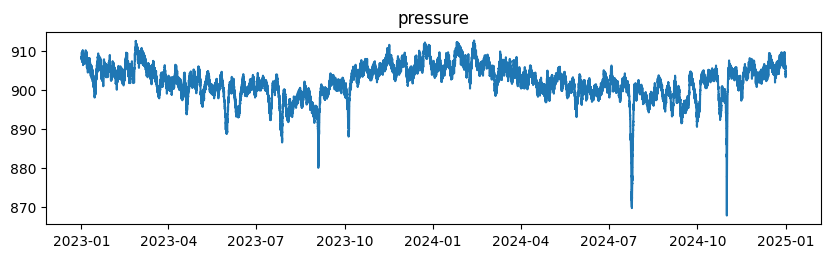

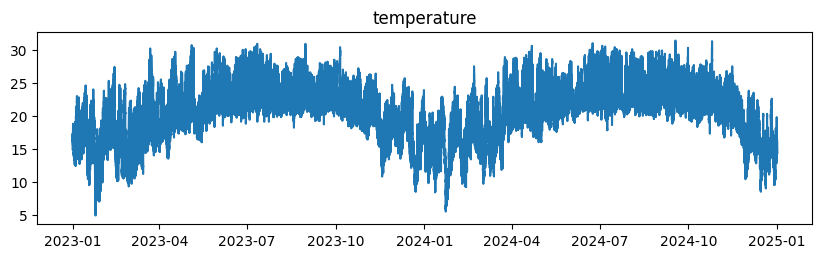

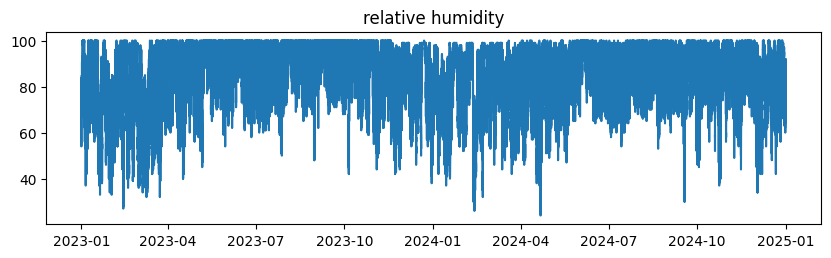

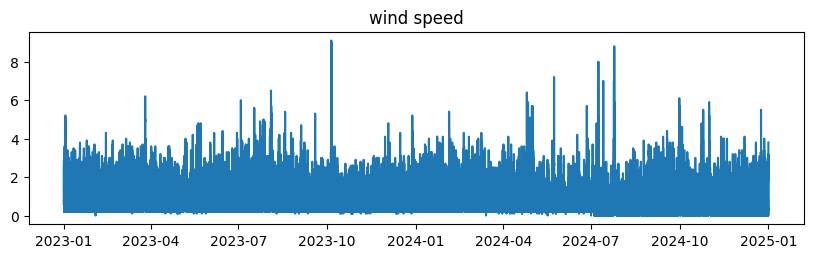

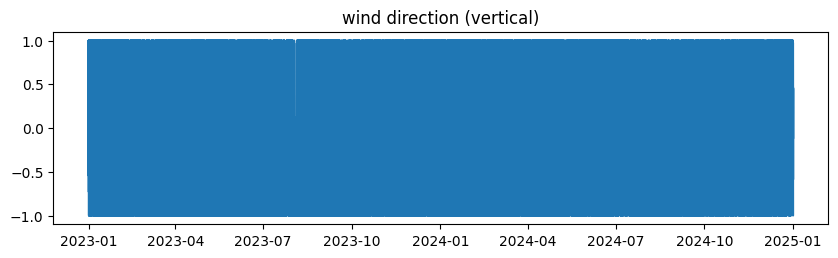

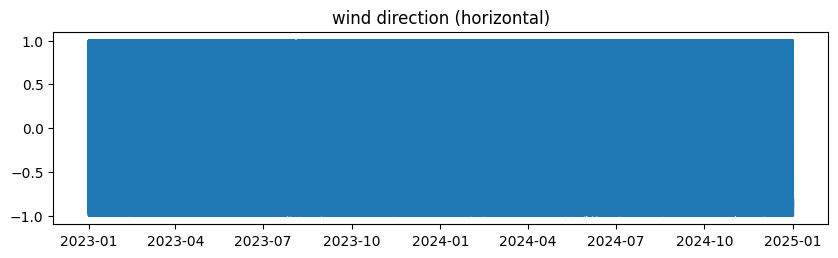

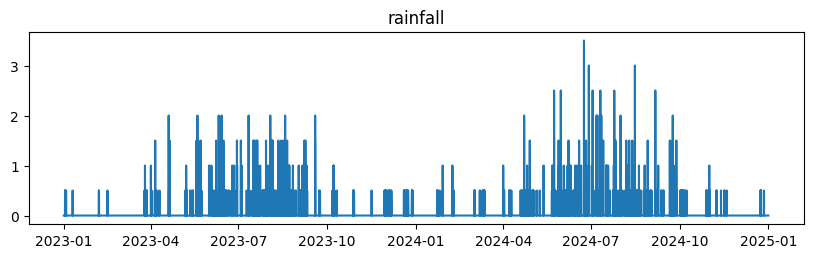

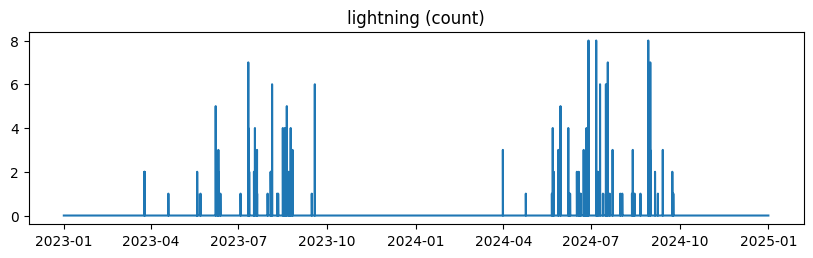

In [1]:
# time-series
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
warnings.filterwarnings("ignore")
df = pd.read_csv("training_df.csv")
df = df.replace("/",np.nan)
df["P"] = df["P"].astype("float").interpolate()
df["T"] = df["T"].astype("float").interpolate()
df["RH"] = df["RH"].astype("float").interpolate()
df["WS"] = df["WS"].astype("float").interpolate()
df["WD"][df["WD"].astype("float") > 360] = np.nan
df["WD"] = df["WD"].astype("float")
df["WD_sin"] = np.sin(df["WD"]*np.pi/180)
df["WD_cos"] = np.cos(df["WD"]*np.pi/180)
df["WD_sin"] = df["WD_sin"].astype("float").interpolate()
df["WD_cos"] = df["WD_cos"].astype("float").interpolate()
df["WD"] = df["WD"].astype("float").interpolate()
df["R"] = df["R"].astype("float").interpolate()
df["timestamp"] = pd.to_datetime(df["timestamp"])
df = df.set_index("timestamp")
plt.figure(figsize=(10,2.5))
plt.plot(df["P"])
plt.title("pressure")
plt.show()
plt.figure(figsize=(10,2.5))
plt.plot(df["T"])
plt.title("temperature")
plt.show()
plt.figure(figsize=(10,2.5))
plt.plot(df["RH"])
plt.title("relative humidity")
plt.show()
plt.figure(figsize=(10,2.5))
plt.plot(df["WS"])
plt.title("wind speed")
plt.show()
plt.figure(figsize=(10,2.5))
plt.plot(df["WD_sin"])
plt.title("wind direction (vertical)")
plt.show()
plt.figure(figsize=(10,2.5))
plt.plot(df["WD_cos"])
plt.title("wind direction (horizontal)")
plt.show()
plt.figure(figsize=(10,2.5))
plt.plot(df["R"])
plt.title("rainfall")
plt.show()
plt.figure(figsize=(10,2.5))
plt.plot(df["lit_counts"])
plt.title("lightning (count)")
plt.show()

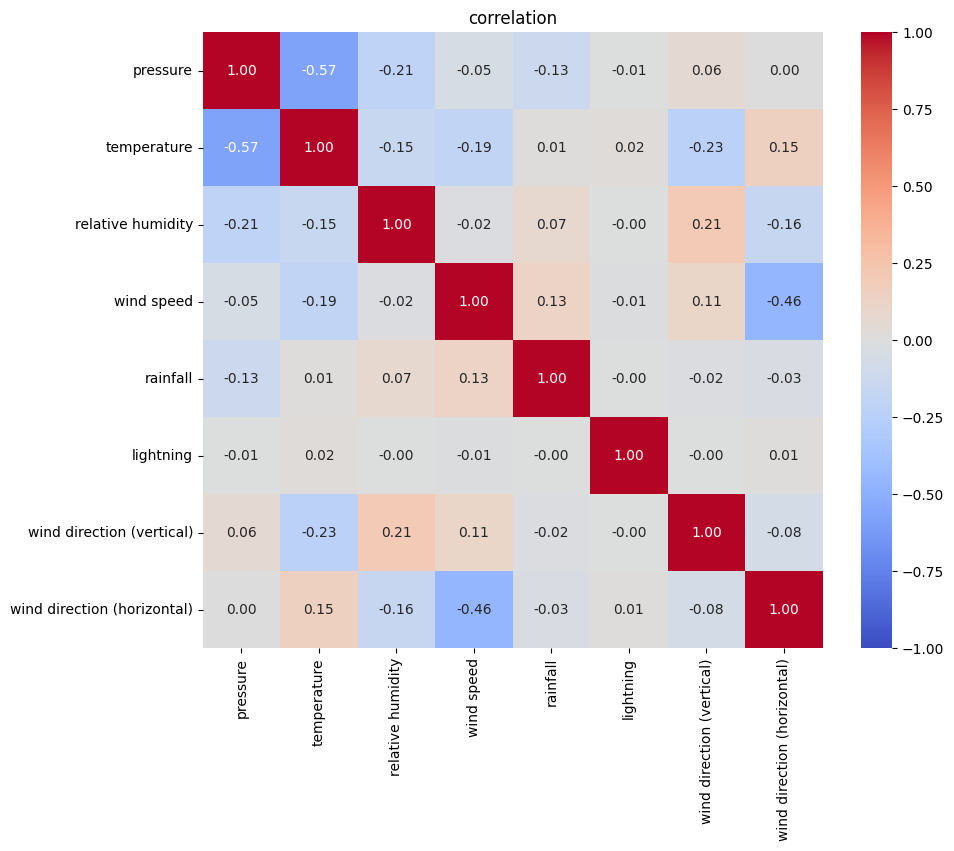

In [39]:
# correlation
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
warnings.filterwarnings("ignore")
df = pd.read_csv("training_df.csv")
df = df.replace("/",np.nan)
df["P"] = df["P"].astype("float").interpolate()
df["T"] = df["T"].astype("float").interpolate()
df["RH"] = df["RH"].astype("float").interpolate()
df["WS"] = df["WS"].astype("float").interpolate()
df["WD"][df["WD"].astype("float") > 360] = np.nan
df["WD"] = df["WD"].astype("float")
df["WD_sin"] = np.sin(df["WD"]*np.pi/180)
df["WD_cos"] = np.cos(df["WD"]*np.pi/180)
df["WD_sin"] = df["WD_sin"].astype("float").interpolate()
df["WD_cos"] = df["WD_cos"].astype("float").interpolate()
df["R"] = df["R"].astype("float").interpolate()
df["timestamp"] = pd.to_datetime(df["timestamp"])
df = df.set_index("timestamp")
df = df.drop(columns=["WD"])
df = df.rename(columns={"P":"pressure","T":"temperature","RH":"relative humidity","WS":"wind speed","R":"rainfall","lit_counts":"lightning","WD_sin":"wind direction (vertical)","WD_cos":"wind direction (horizontal)"})
corr_matrix = df.corr()
plt.figure(figsize=(10,8))
sns.heatmap(corr_matrix,annot=True,cmap="coolwarm",fmt=".2f",vmin=-1,vmax=1)
plt.title("correlation")
plt.show()

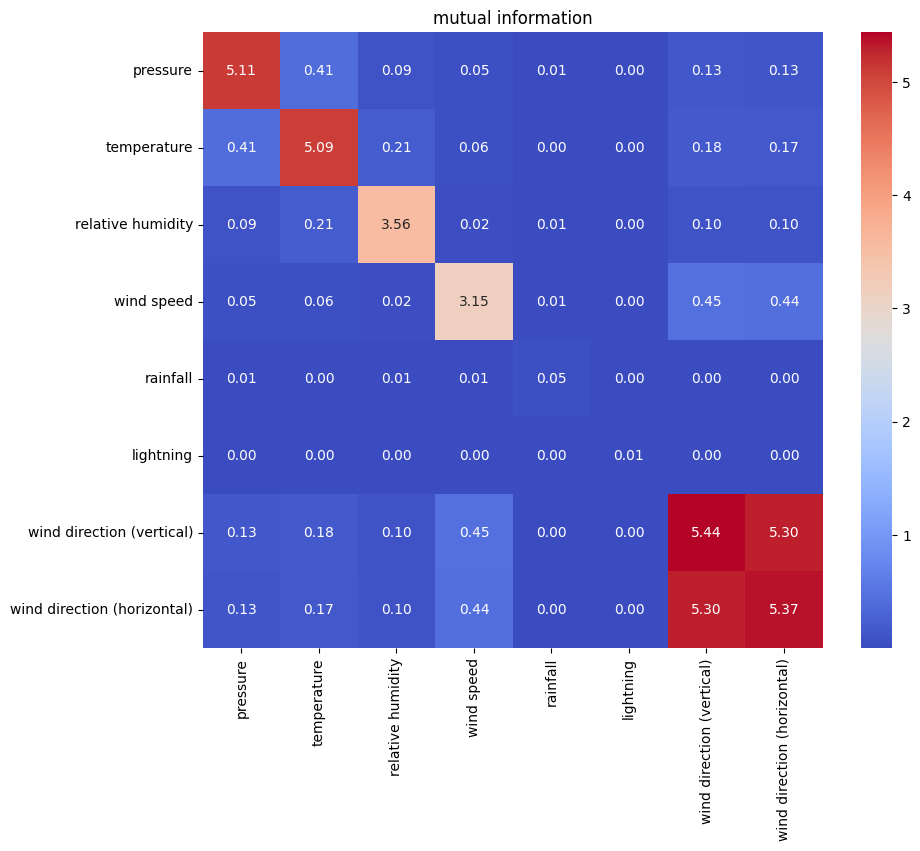

In [40]:
# mutual information
import pandas as pd
import numpy as np
from sklearn.metrics import mutual_info_score
import matplotlib.pyplot as plt
import seaborn as sns
warnings.filterwarnings("ignore")
df = pd.read_csv("training_df.csv")
df = df.replace("/",np.nan)
df["P"] = df["P"].astype("float").interpolate()
df["T"] = df["T"].astype("float").interpolate()
df["RH"] = df["RH"].astype("float").interpolate()
df["WS"] = df["WS"].astype("float").interpolate()
df["WD"][df["WD"].astype("float") > 360] = np.nan
df["WD"] = df["WD"].astype("float")
df["WD_sin"] = np.sin(df["WD"]*np.pi/180)
df["WD_cos"] = np.cos(df["WD"]*np.pi/180)
df["WD_sin"] = df["WD_sin"].astype("float").interpolate()
df["WD_cos"] = df["WD_cos"].astype("float").interpolate()
df["R"] = df["R"].astype("float").interpolate()
df["timestamp"] = pd.to_datetime(df["timestamp"])
df = df.set_index("timestamp")
df = df.drop(columns=["WD"])
df = df.rename(columns={"P":"pressure","T":"temperature","RH":"relative humidity","WS":"wind speed","R":"rainfall","lit_counts":"lightning","WD_sin":"wind direction (vertical)","WD_cos":"wind direction (horizontal)"})
def pairwise_mi(x,y):
    c_matrix = pd.crosstab(x,y)
    return mutual_info_score(None,None,contingency=c_matrix)
cols = df.columns
mi_matrix = pd.DataFrame(index=cols,columns=cols)
for col1 in cols:
    for col2 in cols:
        mi_matrix.loc[col1,col2] = pairwise_mi(df[col1],df[col2])
mi_matrix = mi_matrix.astype(float)
plt.figure(figsize=(10,8))
sns.heatmap(mi_matrix,annot=True,cmap="coolwarm",fmt=".2f")
plt.title("mutual information")
plt.show()

In [1]:
import warnings
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import TensorDataset,DataLoader
from sklearn.metrics import precision_score,recall_score,accuracy_score,f1_score
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix
from sklearn.compose import ColumnTransformer
warnings.filterwarnings("ignore")
torch.manual_seed(42)
np.random.seed(42)

t_inp = 120
t_out = 1
batch_size = 1024
features = 8
node = 64
layer = 2
model_name = "lstm.pth"
result_csv = "result.csv"

df = pd.read_csv("training_df.csv")
df = df.replace("/",np.nan)
df["P"] = df["P"].astype("float").interpolate()
df["T"] = df["T"].astype("float").interpolate()
df["RH"] = df["RH"].astype("float").interpolate()
df["WS"] = df["WS"].astype("float").interpolate()
df["WD"][df["WD"].astype("float") > 360] = np.nan
df["WD"] = df["WD"].astype("float")
df["WD_sin"] = np.sin(df["WD"]*np.pi/180)
df["WD_cos"] = np.cos(df["WD"]*np.pi/180)
df["WD_sin"] = df["WD_sin"].astype("float").interpolate()
df["WD_cos"] = df["WD_cos"].astype("float").interpolate()
df["R"] = df["R"].astype("float").interpolate()
df["timestamp"] = pd.to_datetime(df["timestamp"])
df = df.set_index("timestamp")
df = df.drop(columns=["WD"])
df = df.resample("60min").agg({
    "P": "median",
    "T": "median",
    "RH": "median",
    "WS": "median",
    "WD_sin": "median",
    "WD_cos": "median",
    "R": "sum",
    "lit_counts": "sum"
})
df.loc[df["lit_counts"]>0,"lit_counts"] = 1
for i in range(t_inp,0,-1):
    df["t-"+str(i)+"_P"] = df["P"].shift(i)
    df["t-"+str(i)+"_T"] = df["T"].shift(i)
    df["t-"+str(i)+"_RH"] = df["RH"].shift(i)
    df["t-"+str(i)+"_WS"] = df["WS"].shift(i)
    df["t-"+str(i)+"_WD_sin"] = df["WD_sin"].shift(i)
    df["t-"+str(i)+"_WD_cos"] = df["WD_cos"].shift(i)
    df["t-"+str(i)+"_R"] = df["R"].shift(i)
    df["t-"+str(i)+"_lit_counts"] = df["lit_counts"].shift(i)
for i in range(0,-t_out,-1):
    df["t+"+str(abs(i))+"_lit_counts"] = df["lit_counts"].shift(i)
df = df.dropna()
df = df.drop(columns=["P","T","RH","WS","WD_sin","WD_cos","R","lit_counts"])
X_train = df[df.index.year == 2023].drop(columns=df.filter(like="t+",axis=1).columns).to_numpy()
y_train = df[df.index.year == 2023].filter(like="t+",axis=1).to_numpy()
X_test = df[df.index.year == 2024].drop(columns=df.filter(like="t+",axis=1).columns).to_numpy()
y_test = df[df.index.year == 2024].filter(like="t+",axis=1).to_numpy()
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)
X_train = X_train.reshape((X_train.shape[0],X_train.shape[1]//features,features))
X_test = X_test.reshape((X_test.shape[0],X_test.shape[1]//features,features))
split_idx = int(len(X_train)*0.5)
X_train_split = X_train[:split_idx]
y_train_split = y_train[:split_idx]
X_val_split = X_train[split_idx:]
y_val_split = y_train[split_idx:]
X_train_tensor = torch.tensor(X_train_split,dtype=torch.float32)
y_train_tensor = torch.tensor(y_train_split,dtype=torch.float32)
X_val_tensor = torch.tensor(X_val_split,dtype=torch.float32)
y_val_tensor = torch.tensor(y_val_split,dtype=torch.float32)
X_test_tensor = torch.tensor(X_test,dtype=torch.float32)
y_test_tensor = torch.tensor(y_test,dtype=torch.float32)
train_dataset = TensorDataset(X_train_tensor,y_train_tensor)
train_loader = DataLoader(train_dataset,batch_size=batch_size,shuffle=True)
val_dataset = TensorDataset(X_val_tensor,y_val_tensor)
val_loader = DataLoader(val_dataset,batch_size=batch_size,shuffle=False)
train_log = []
val_log = []
class LSTMModel(nn.Module):
    def __init__(self,input_size,hidden_size,out_size,num_layers=2,dropout_prob=0.2):
        super(LSTMModel,self).__init__()
        self.lstm = nn.LSTM(input_size=input_size,hidden_size=hidden_size,num_layers=num_layers,batch_first=True,dropout=dropout_prob)
        self.dropout = nn.Dropout(dropout_prob)
        self.fc = nn.Linear(hidden_size,out_size)
    def forward(self,x):
        out,_ = self.lstm(x)
        out = out[:,-1,:]
        out = self.fc(out)
        return out
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = LSTMModel(input_size=features,hidden_size=node,num_layers=layer,out_size=t_out).to(device)
class BCEFocalLoss(nn.Module):
    def __init__(self,alpha=0.25,gamma=2,reduction="mean"):
        super(BCEFocalLoss,self).__init__()
        self.alpha = alpha
        self.gamma = gamma
        self.reduction = reduction
    def forward(self,inputs,targets):
        bce_loss = F.binary_cross_entropy_with_logits(inputs,targets,reduction="none")
        p = torch.sigmoid(inputs)
        p_t = p*targets+(1-p)*(1-targets)
        focal_term = (1-p_t)**self.gamma
        alpha_t = self.alpha*targets+(1-self.alpha)*(1-targets)
        loss = alpha_t*focal_term*bce_loss
        if self.reduction == "mean":
            return loss.mean()
        elif self.reduction == "sum":
            return loss.sum()
        else:
            return loss
num_pos = np.sum(y_train_split)
num_neg = len(y_train_split)-num_pos
alpha_value = num_neg/(num_pos+num_neg)
criterion = BCEFocalLoss(alpha=alpha_value,gamma=4)
optimizer = torch.optim.Adam(model.parameters(),lr=1e-2)
train_log = []
val_log = []
epochs = 1000
patience = 10
best_val_loss = float("inf")
epochs_no_improve = 0
for epoch in range(epochs):
    model.train()
    train_loss = 0.0
    for X_batch,y_batch in train_loader:
        X_batch,y_batch = X_batch.to(device),y_batch.to(device)
        optimizer.zero_grad()
        outputs = model(X_batch)
        loss = criterion(outputs,y_batch)
        loss.backward()
        optimizer.step()
        train_loss += loss.item() * X_batch.size(0)
    train_loss /= len(train_loader.dataset)
    model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for X_batch,y_batch in val_loader:
            X_batch,y_batch = X_batch.to(device),y_batch.to(device)
            outputs = model(X_batch)
            loss = criterion(outputs,y_batch)
            val_loss += loss.item() * X_batch.size(0)
    val_loss /= len(val_loader.dataset)
    train_log.append(train_loss)
    val_log.append(val_loss)
    print("epoch:",epoch+1," train loss:",train_loss," val loss:",val_loss)
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        epochs_no_improve = 0
        torch.save(model.state_dict(),model_name)
    else:
        epochs_no_improve += 1
        if epochs_no_improve >= patience:
            print(f"early stopping triggered at epoch {epoch+1}")
            break
model.load_state_dict(torch.load(model_name))
model.eval()
val_preds = []
with torch.no_grad():
    for X_batch,_ in val_loader:
        preds = model(X_batch.to(device)).cpu().numpy()
        val_preds.append(preds)
y_val_pred_prob = np.concatenate(val_preds,axis=0)
best_thresh = np.full((y_val_split.shape[1]),0.5)
best_csi = np.full((y_val_split.shape[1]),0.0)
for i in range(y_val_split.shape[1]):
    for thresh in np.arange(0.01,1.0,0.01):
        temp_preds = np.where(y_val_pred_prob>thresh,1,0)
        tn,fp,fn,tp = confusion_matrix(y_val_split[:,i],temp_preds[:,i]).ravel()
        score = tp/(tp+fp+fn)
        if score > best_csi[i]:
            best_csi[i] = score
            best_thresh[i] = thresh
    print(f"optimal threshold found: {best_thresh[i]:.2f} (CSI: {best_csi[i]:.4f})")
model.eval()
all_preds = []
with torch.no_grad():
    for i in range(0,len(X_train_tensor),batch_size):
        batch_X = X_train_tensor[i:i+batch_size]
        preds = model(batch_X.to(device)).cpu().numpy()
        all_preds.append(preds)
        if torch.cuda.is_available():
            torch.cuda.empty_cache()
y_pred = np.concatenate(all_preds,axis=0)
for i in range(y_pred.shape[1]):
    y_pred[:,i] = np.where(y_pred[:,i]>best_thresh[i],1,0)
    tn,fp,fn,tp = confusion_matrix(y_train_split[:,i],y_pred[:,i]).ravel()
    train_precision = precision_score(y_train_split[:,i],y_pred[:,i])
    train_recall = recall_score(y_train_split[:,i],y_pred[:,i])
    train_accuracy = accuracy_score(y_train_split[:,i],y_pred[:,i])
    train_f1 = f1_score(y_train_split[:,i],y_pred[:,i])
    train_csi = tp/(tp+fp+fn)
    print("train tn:",tn," fp:",fp," fn: ",fn," tp: ",tp)
    print("train f1:",train_f1)
    print("train csi",train_csi)
model.eval()
all_preds = []
with torch.no_grad():
    for i in range(0,len(X_test_tensor),batch_size):
        batch_X = X_test_tensor[i:i+batch_size]
        preds = model(batch_X.to(device)).cpu().numpy()
        all_preds.append(preds)
        if torch.cuda.is_available():
            torch.cuda.empty_cache()
y_pred = np.concatenate(all_preds,axis=0)
for i in range(y_pred.shape[1]):
    y_pred[:,i] = np.where(y_pred[:,i]>best_thresh[i],1,0)
    tn,fp,fn,tp = confusion_matrix(y_test[:,i],y_pred[:,i]).ravel()
    test_precision = precision_score(y_test[:,i],y_pred[:,i])
    test_recall = recall_score(y_test[:,i],y_pred[:,i])
    test_accuracy = accuracy_score(y_test[:,i],y_pred[:,i])
    test_f1 = f1_score(y_test[:,i],y_pred[:,i])
    test_csi = tp/(tp+fp+fn)
    print("test tn:",tn," fp:",fp," fn: ",fn," tp: ",tp)
    print("test f1:",test_f1)
    print("test csi:",test_csi)
    print("test POD:",tp/(tp+fn))
df_log = pd.DataFrame()
df_log["train_loss"] = train_log
df_log["val_loss"] = val_log
df_log.to_csv(result_csv)

epoch: 1  train loss: 0.0003316850463980464  val loss: 0.0005013421941906994
epoch: 2  train loss: 0.00033370883751626093  val loss: 0.0005491143389479947
epoch: 3  train loss: 0.00024713040566658255  val loss: 0.00046151884237554406
epoch: 4  train loss: 0.00022819632571621762  val loss: 0.00044166187039485925
epoch: 5  train loss: 0.0002025175333579278  val loss: 0.0004926661357617209
epoch: 6  train loss: 0.00020506610157166574  val loss: 0.00045943607237185696
epoch: 7  train loss: 0.00016993463003826844  val loss: 0.0005844488085265901
epoch: 8  train loss: 0.00015043058148067858  val loss: 0.000492415339296578
epoch: 9  train loss: 0.00014824057407504705  val loss: 0.0004227808667363004
epoch: 10  train loss: 0.00020367686283188287  val loss: 0.0005084572185027086
epoch: 11  train loss: 0.00019869129723196641  val loss: 0.0006098596172604529
epoch: 12  train loss: 0.00016091092882022538  val loss: 0.0005294393393224136
epoch: 13  train loss: 0.00014531571241268128  val loss: 0.00